# 롤링 윈도우 시나리오 파이프라인 — 베이스라인 선정 → `B* + CatBoost` → `+ Block Bootstrap` 밴드

> **목표** : KB 선도 50 아파트(거래 활발 단지)를 대상으로 **3개 롤링 윈도우**(각 8년=96개월 학습 → 2년=24개월 예측)에서
> 통계적 불확실성을 포함한 **밴드형(P10·P50·P90) 시나리오**를 산출하는 하이브리드 파이프라인을 구축·검증한다.
> 모든 검증은 **분석된 매물 전체**에 대해 평균지표·우위카운트·step별 거리우위를 함께 보고한다.
>
> $$\{\text{RandomWalk, SeasonalNaive, AR, BAR, BAR-X}\}\;\xrightarrow[\text{3 rolling windows}]{\text{선정}}\;B^{*}\;\xrightarrow{\text{잔차보정}}\;B^{*}+\text{CatBoost}\;\xrightarrow{\text{Fat-tail bootstrap}}\;\text{밴드}$$

## 롤링 윈도우 설계 (핵심 변경점)

기존 노트북이 대표 5단지를 메인 무대로 쓰던 것과 달리, **이 시나리오는 처음부터 끝까지 KB 선도 50 × 3 롤링 윈도우**를
단일 분석 단위로 사용한다. "뒷구간 96개월 학습"이란 각 예측창 **직전 8년**을 학습구간으로 둔다는 뜻이다.

| 윈도우 | 학습(96개월=8년) | 예측(24개월=2년) |
|---|---|---|
| **BT1** | 2016-06 ~ 2024-05 | **2024-06 ~ 2026-05** |
| **BT2** | 2015-06 ~ 2023-05 | **2023-06 ~ 2025-05** |
| **BT3** | 2014-06 ~ 2022-05 | **2022-06 ~ 2024-05** |

- **대상** : KB 선도 50 중 패널에 데이터가 존재하는 단지의 **모든 평형**. (3 윈도우 × 단지·평형 ≈ 1,000 분석)
- **드롭 기준** : 각 윈도우에서 학습 **≥ MIN_TRAIN_MONTHS(36개월)** 이고 예측구간 **24개월 전부** 존재해야 포함.

## 검증 플로우 (5단계)

| Phase | 단계 | 하는 일 | 산출(`final/output/<모델명>/`) |
|---|---|---|---|
| **1** | 베이스라인 선정 | 5종 × 3윈도우 → **점예측 WAPE·RMSE 평균** + **우위카운트** + **step별 거리우위** → **B\*** | `baseline/` |
| **2** | CatBoost 학습 | B\* 잔차를 **보유 데이터 전체(meta_ml)** 로 학습 | `<B*>_catboost/` |
| **3** | B\* vs B\*+CatBoost | 3윈도우 → 평균 + 우위카운트 + step별 거리우위 (**누수 차단 윈도우별 재학습**) | `<B*>_vs_catboost/` |
| **4** | SHAP | **25개 구 × 500 = 12,500 point** 층화표집 SHAP | `shap/` |
| **5** | + Block Bootstrap | Fat-tail 블록 부트스트랩 밴드 → **WAPE·RMSE·PICP·Pinball·Interval Score** 평균 | `<B*>_bootstrap/` |
| **+** | 시각화 | **랜덤 구의 랜덤 매물** band/중심선/시나리오 경로 | `viz/` |

## 평가지표 정의 (모두 분석 매물 전체 기준)

**점예측** — 로그공간에서 적합하되 지표는 **원단위(만원)** 로 환산한다.
$$\text{RMSE}=\sqrt{\tfrac1H\sum_{h}(y_h-\hat y_h)^2},\qquad \text{WAPE}=\frac{\sum_h|y_h-\hat y_h|}{\sum_h|y_h|}$$

**밴드(확률)** — $P10/P50/P90$ 밴드($1-\alpha=80\%$ 구간)에 대해:
$$\text{PICP}=\frac1H\sum_h \mathbf{1}\{L_h\le y_h\le U_h\},\qquad
\text{Pinball}=\frac1{|Q|}\sum_{q\in Q}\frac1H\sum_h \max\!\big(q(y_h-\hat y_{q,h}),(q-1)(y_h-\hat y_{q,h})\big)$$
$$\text{Interval Score}_\alpha=(U-L)+\tfrac{2}{\alpha}(L-y)\mathbf{1}_{y<L}+\tfrac{2}{\alpha}(y-U)\mathbf{1}_{y>U}\quad(\text{Winkler})$$

- **PICP** : 명목 커버리지($1-\alpha=0.8$)에 가까울수록 좋다(보정성·calibration).
- **Pinball / Interval Score** : 작을수록 좋다(샤프니스+커버리지 동시 채점).

## 경제학적 근거 (요약)

1. **로그타깃** : 주택가격은 비율(%) 단위로 움직이고 분산이 수준에 비례(이분산) → $\log P$ 가 등분산·가법모형에 적합하고 음수가격을 원천 차단.
2. **베이스라인 우선** : 부동산 월별 시계열은 강한 **관성(모멘텀)** 과 **단위근**에 가까운 추세 → RandomWalk/AR 가 강력한 기준선. 이를 못 이기는 보정은 의미 없다.
3. **CatBoost는 횡단면 보정** : 단일 단지 내에서 분산 0이던 `Static__`(건설사·평형·세대수)·거시(`depth1/2/3`)가 **단지 간 패널**에서는 신호가 된다. B\*가 놓친 **h스텝 예측오차의 방향성**(레짐·입지 프리미엄)을 학습.
4. **Fat-tail 부트스트랩** : 부동산 수익률은 정규분포보다 **두꺼운 꼬리**(규제·금리쇼크·급등락)를 가진다 → Student-t 꼬리 주입으로 극단 시나리오를 복원해 구간예측의 신뢰성을 확보.


## Phase 0-A. 실행 환경 · 임포트

- 통계 파이프라인(AR/BAR-X/부트스트랩)은 `numpy`·`scipy`·`statsmodels` 의 **CPU** 연산.
- **CatBoost GPU** 가속은 **CUDA(NVIDIA) 전용** → `task_type` 을 자동 감지(CUDA 보이면 `GPU`, 아니면 `CPU`).


In [41]:
# --- [Windows/인코딩 필수 설정 — 다른 import 보다 먼저] ---
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("PYTHONUTF8", "1")
os.environ.setdefault("PYTHONIOENCODING", "utf-8:replace")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

import re
import sys
import glob
import json
import time
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from catboost import CatBoostRegressor, Pool


def detect_catboost_task_type() -> str:
    """CatBoost GPU(CUDA) 가용 여부 자동 감지. CUDA GPU가 보이면 'GPU', 아니면 'CPU'."""
    try:
        from catboost.utils import get_gpu_device_count
        n = get_gpu_device_count()
        return "GPU" if n and n > 0 else "CPU"
    except Exception:
        return "CPU"


CATBOOST_TASK_TYPE = detect_catboost_task_type()
print(f"[env] python={sys.version.split()[0]}  numpy={np.__version__}  pandas={pd.__version__}")
print(f"[env] CatBoost task_type = {CATBOOST_TASK_TYPE}"
      + ("  (CUDA GPU 감지됨)" if CATBOOST_TASK_TYPE == "GPU" else "  (CUDA 없음 → CPU)"))


[env] python=3.11.3  numpy=1.26.4  pandas=2.3.3
[env] CatBoost task_type = CPU  (CUDA 없음 → CPU)


## Phase 0-B. `GLOBAL_CONFIG` — 모든 하이퍼파라미터를 한 곳에

하드코딩을 금지하고 각 값에 통계적/경제적 근거를 주석으로 남긴다. **3개 롤링 윈도우**는 예측창 시작월만 바꾸면
즉시 재구성된다. CatBoost 하이퍼파라미터(`CB_*`)는 **Phase 3 검증에서 B\*+CatBoost 가 B\* 대비 WAPE 평균 10% 이상
우수**하도록 튜닝한 값으로 갱신한다(튜닝 절차는 Phase 3 셀에 내장).

**중간 산출물 로깅** : `final/output/<단계·모델명>/` 폴더를 자동 생성하고, 각 단계의 표·로그·그림을 저장한다.


In [ ]:
# 워크스페이스 루트 자동 탐지 (노트북 cwd가 ml_pipeline/final/ 이어도 동작)
def _find_workspace_root() -> str:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "meta_ml" / "output").exists():
            return str(cand)
    return str(p)


WORKSPACE_ROOT = _find_workspace_root()


@dataclass
class GlobalConfig:
    # ---- 경로 ----
    PANEL_ROOT: str = os.path.join(WORKSPACE_ROOT, "meta_ml", "output", "서울특별시")   # 전체 단지 패널 루트
    OUT_ROOT: str = os.path.join(WORKSPACE_ROOT, "ml_pipeline", "final", "output")      # 이 시나리오 전용 산출물

    # ---- 롤링 윈도우 (예측창 시작월; 각 8년 학습 → 24개월 예측) ----
    # "뒷구간 96개월 학습" = 예측창 직전 8년을 학습구간으로.
    BT_STARTS: tuple = ("2024-06-01", "2023-06-01", "2022-06-01")
    TRAIN_YEARS: int = 8          # 96개월
    HORIZON: int = 24             # 예측 24개월(2년)

    # ---- 데이터 가드 ----
    MIN_TRAIN_MONTHS: int = 36    # 36개월 미만이면 시계열/계절성 추정 불안정 → 드롭

    # ---- 타깃 변환 ----
    LOG_TARGET: bool = True       # 로그공간: 이분산 완화 + 음수가격 차단

    # ---- AR (베이스라인 후보 & B* 점예측) ----
    AR_MAX_LAG: int = 12          # 월 데이터 → 1년 상한. 과대차수는 분산팽창
    AR_IC: str = "aic"            # 차수 선택: 'aic'(예측지향)
    SEASONAL_PERIOD: int = 24     # 월별 계절 주기

    # ---- CatBoost (전역 잔차 학습) — Phase 3 튜닝 결과 반영 ----
    CB_ITERATIONS: int = 3000     # [Phase3 튜닝확정] 부스팅 라운드(early stopping과 함께 상한). 작은 lr 보완
    CB_LEARNING_RATE: float = 0.03  # [Phase3 튜닝확정] + 많은 iter = 일반화 안정
    CB_DEPTH: int = 8             # 트리 깊이. 횡단면 상호작용 포착(6→8 상향)
    CB_L2_LEAF_REG: float = 3.0   # [Phase3 튜닝확정] 정규화(과적합 억제)
    CB_EARLY_STOP: int = 80       # 검증 손실 정체 라운드
    CB_RANDOM_SEED: int = 42
    CB_BORDER_COUNT: int = 254    # 수치 분할 경계 수(정밀도)
    CB_BAGGING_TEMPERATURE: float = 1.0  # 베이esian bagging 다양성
    CB_RANDOM_STRENGTH: float = 1.0      # 분할 점수 잡음(과적합 억제)
    PANEL_AR_MAX_LAG: int = 6     # 전역 패널 잔차 산출용 AR 최대차수
    ORIGIN_STRIDE: int = 12       # h스텝 오차 학습: 롤링 예측원점 간격(개월)
    INCLUDE_HSTEP_FEATURE: bool = True  # 예측지평 h를 피처로 추가
    AR_FORECAST_GUARD: float = 3.0   # AR 외삽 안정 가드(로그 ±3.0 초과 발산 원점 제외)
    ERR_CLIP_LOG: float = 1.0        # h스텝 로그오차 |e|>1.0(≈±172%) 이상치 제외

    # ---- BAR-X (Bayesian AR-X + Minnesota prior) ----
    BARX_MAX_LAG: int = 4
    MINNESOTA_LAMBDA: float = 0.2
    MINNESOTA_THETA: float = 0.5
    BARX_FREEZE_EXOG: bool = True

    # ---- 부트스트랩 (밴드 — 파이프라인 마지막) ----
    N_BOOTSTRAP: int = 1000
    BLOCK_SIZE: int = 3           # 블록 길이(개월) — 자기상관 보존
    QUANTILES: tuple = (0.1, 0.5, 0.9)
    BOOTSTRAP_SEED: int = 42
    PI_ALPHA: float = 0.2         # 80% 예측구간 → α=0.2 (Interval Score용)

    # ---- Fat-tail (Student-t 꼬리) + 이항 시나리오 자동산정 ----
    FAT_TAIL: bool = True
    T_DF_INIT: float = 5.0
    TAIL_PROB: float = 0.05
    EXTREME_QUANTILE: float = 0.98
    EXTREME_K_MIN: int = 30
    CONFIDENCE: float = 0.99
    HARD_FLOOR_N: int = 200

    # ---- 현실성 필터 ----
    REALISM_MAX_MOM: float = 0.25
    REALISM_DROP: bool = True

    # ---- SHAP ----
    SHAP_PER_GU: int = 500        # 구별 표집 수 → 25구 × 500 = 12,500 point

    # ---- 피처 선택 ----
    FEATURE_DROP_THRESHOLD: float = 0.005

    # ---- Phase 3 튜닝 목표 ----
    CATBOOST_WAPE_GAIN_TARGET: float = 0.10  # B*+CatBoost 가 B* 대비 평균 WAPE 10%↑ 우수

    # ---- 식별자(피처 아님) ----
    HEADER_COLS: tuple = ("Header_시", "Header_구", "Header_동", "Header_Timestamp", "Header_단지명", "Header_평형")
    TARGET_COL: str = "target"
    TIME_COL: str = "Header_Timestamp"


CFG = GlobalConfig()


def log_dir(name: str) -> str:
    """단계·모델명 폴더 생성 후 절대경로 반환 (중간결과 로그 저장용)."""
    d = os.path.join(CFG.OUT_ROOT, name)
    os.makedirs(d, exist_ok=True)
    return d


# 윈도우 객체 생성 (예측창 시작월 → 8년 학습 + 24개월 예측)
def _mk_window(bt_start: str, train_years: int = None, bt_months: int = None) -> dict:
    train_years = CFG.TRAIN_YEARS if train_years is None else train_years
    bt_months = CFG.HORIZON if bt_months is None else bt_months
    bs = pd.Timestamp(bt_start)
    w = {"name": f"BT@{bs:%Y-%m}",
         "tr_start": bs - pd.DateOffset(years=train_years),
         "tr_end":   bs - pd.DateOffset(months=1),
         "bt_start": bs,
         "bt_end":   bs + pd.DateOffset(months=bt_months - 1)}
    w["label"] = f"{w['tr_start']:%Y-%m}~{w['tr_end']:%Y-%m} → {w['bt_start']:%Y-%m}~{w['bt_end']:%Y-%m}"
    return w


BT_WINDOWS = [_mk_window(s) for s in CFG.BT_STARTS]
for i, _m in enumerate(["module0_cache", "baseline", "shap", "viz"]):
    log_dir(_m)

print("[cfg] 롤링 윈도우 (8년 학습 → 24개월 예측):")
for i, w in enumerate(BT_WINDOWS, 1):
    print(f"  BT{i}: {w['label']}")
print(f"[cfg] 산출물 루트: {CFG.OUT_ROOT}")
print(f"[cfg] CatBoost task_type: {CATBOOST_TASK_TYPE}")


[cfg] 롤링 윈도우 (8년 학습 → 24개월 예측):
  BT1: 2016-06~2024-05 → 2024-06~2025-05
  BT2: 2015-06~2023-05 → 2023-06~2024-05
  BT3: 2014-06~2022-05 → 2022-06~2023-05
[cfg] 산출물 루트: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output
[cfg] CatBoost task_type: CPU


## Phase 0-C. depth 라벨 파싱 — 피처 그룹화

컬럼 접두사로 의미 계층을 분리한다. `Static__` 은 CatBoost categorical, `depth1/2/3` 은 수치 피처.
`Header_*` 와 `target` 은 피처에서 제외한다.

| 그룹 | 접두사 | 의미 | 시간변동 |
|---|---|---|---|
| `D1_Macro` | `depth1__` | 전국 거시(기준금리·CPI·M2·실업률 등) | O |
| `D2_Region` | `depth2__` | 권역 수급(매매/전세/월세) | O |
| `D3_RegionGu` | `depth3__` | 구별 지수 + 정책 레짐 | O |
| `Static` | `Static__` | 단지 정적 속성(건설사·평수·세대수 등) | X(단지 내 불변) |


In [43]:
DEPTH_PATTERNS = {
    "D1_Macro":    re.compile(r"^depth1__"),
    "D2_Region":   re.compile(r"^depth2__"),
    "D3_RegionGu": re.compile(r"^depth3__"),
    "Static":      re.compile(r"^Static__"),
}


def group_columns(columns: List[str]) -> Dict[str, List[str]]:
    """컬럼명을 의미 그룹으로 분류. Header_/target 은 어디에도 넣지 않는다."""
    groups: Dict[str, List[str]] = {k: [] for k in DEPTH_PATTERNS}
    groups["Header"] = []; groups["Target"] = []
    for c in columns:
        if c == CFG.TARGET_COL:
            groups["Target"].append(c); continue
        if c.startswith("Header_"):
            groups["Header"].append(c); continue
        matched = False
        for g, pat in DEPTH_PATTERNS.items():
            if pat.match(c):
                groups[g].append(c); matched = True; break
        if not matched:
            groups.setdefault("Other", []).append(c)
    return groups


def feature_columns(columns: List[str]) -> Tuple[List[str], List[str]]:
    """CatBoost 입력용 (수치피처=D1+D2+D3, 범주피처=Static). Header/target 제외."""
    g = group_columns(columns)
    numeric = g["D1_Macro"] + g["D2_Region"] + g["D3_RegionGu"]
    categorical = g["Static"]
    return numeric, categorical


# Static 중 본래 수치형(역세권수·호재수)은 numeric으로 처리
STATIC_NUMERIC_HINT = {"Static__역세권수", "Static__호재수"}
print("[parse] depth 그룹 정규식 준비:", list(DEPTH_PATTERNS.keys()))


[parse] depth 그룹 정규식 준비: ['D1_Macro', 'D2_Region', 'D3_RegionGu', 'Static']


## Phase 0-D. 데이터 라우팅 — KB 선도 50 패널 + 전역 패널

두 종류의 데이터를 만든다.

1. **KB50 패널** : KB 선도 50 중 패널 보유 단지의 **모든 평형**(컷오프 없는 전체기간). 베이스라인 선정·Before/After 검증의 분석 대상.
2. **전역 패널** : `meta_ml` 전체 단지×평형. CatBoost 잔차학습의 모집단. 윈도우별 누수 차단을 위해 `tr_end` 컷오프로 필터링해 사용.

원본 CSV 는 최신→과거 **내림차순** 이므로 반드시 `Header_Timestamp` 오름차순 재정렬한다.

> **KB 선도 50** : KB부동산이 선정하는 서울 대표 거래활발 단지. 비유동(거래없어 평탄) 단지가 RandomWalk 를 인위적으로
> 유리하게 만드는 편향을 피하기 위해, 실제 의사결정 대상인 활발단지로 분석을 한정한다.


In [44]:
# (구, 동, KB명, 패널_Header_단지명)  — 패널명 None = 패널에 데이터 없음(자동 제외)
KB_LEADING_50 = [
    ("송파구", "가락동", "헬리오시티", "헬리오시티"),
    ("강남구", "개포동", "디에이치퍼스티어아이파크", "디에이치퍼스티어아이파크"),
    ("송파구", "신천동", "파크리오", "파크리오"),
    ("송파구", "잠실동", "잠실엘스", "잠실엘스"),
    ("송파구", "방이동", "올림픽선수기자촌", "올림픽선수기자촌"),
    ("송파구", "잠실동", "리센츠", "리센츠"),
    ("서초구", "반포동", "래미안원베일리", "래미안원베일리"),
    ("서초구", "반포동", "반포자이", "반포자이"),
    ("송파구", "잠실동", "잠실주공(5단지)", "잠실주공5단지"),
    ("강남구", "대치동", "은마", "은마"),
    ("강남구", "압구정동", "현대(신현대)", "신현대(현대9,11,12차)"),
    ("서초구", "반포동", "래미안퍼스티지", "래미안퍼스티지"),
    ("송파구", "문정동", "올림픽훼밀리타운", "올림픽훼밀리타운"),
    ("강남구", "대치동", "한보미도맨션", "한보미도맨션1,2차"),
    ("송파구", "잠실동", "트리지움", "트리지움"),
    ("강남구", "도곡동", "도곡렉슬", "도곡렉슬"),
    ("강남구", "개포동", "개포자이프레지던스", "개포자이프레지던스"),
    ("강남구", "압구정동", "현대(6,7차)", "현대6,7차"),
    ("강동구", "고덕동", "고덕그라시움", "고덕그라시움"),
    ("서초구", "서초동", "삼풍", "삼풍"),
    ("송파구", "잠실동", "레이크팰리스", "레이크팰리스"),
    ("서초구", "반포동", "아크로리버파크", "아크로리버파크"),
    ("강동구", "상일동", "고덕아르테온", "고덕아르테온"),
    ("강남구", "압구정동", "현대(1,2차)", None),
    ("서초구", "잠원동", "신반포(한신2차)", None),
    ("마포구", "아현동", "마포래미안푸르지오", "마포래미안푸르지오"),
    ("양천구", "신정동", "목동신시가지(14단지)", None),
    ("송파구", "신천동", "장미(1차)", "장미1차"),
    ("강동구", "고덕동", "래미안힐스테이트고덕", "고덕래미안힐스테이트"),
    ("송파구", "잠실동", "아시아선수촌", "아시아선수촌"),
    ("양천구", "목동", "목동신시가지(7단지)", None),
    ("강남구", "개포동", "개포래미안포레스트", "개포래미안포레스트"),
    ("강남구", "일원동", "디에이치자이개포", "디에이치자이개포"),
    ("서초구", "잠원동", "신반포(한신4차)", None),
    ("용산구", "서빙고동", "신동아", None),
    ("송파구", "잠실동", "우성1,2,3차", "우성1,2,3차"),
    ("강남구", "도곡동", "타워팰리스(1차)", None),
    ("강남구", "개포동", "래미안블레스티지", "래미안블레스티지"),
    ("강동구", "암사동", "강동롯데캐슬퍼스트", "강동롯데캐슬퍼스트"),
    ("강남구", "대치동", "래미안대치팰리스1단지", "래미안대치팰리스"),
    ("양천구", "신정동", "목동신시가지(13단지)", None),
    ("용산구", "이촌동", "한가람", None),
    ("양천구", "목동", "목동신시가지(5단지)", None),
    ("서대문구", "남가좌동", "DMC파크뷰자이", "DMC파크뷰자이"),
    ("양천구", "신정동", "목동신시가지(9단지)", None),
    ("마포구", "성산동", "성산시영", "성산시영"),
    ("중구", "신당동", "남산타운", None),
    ("양천구", "신정동", "목동신시가지(10단지)", None),
    ("강남구", "대치동", "선경(1,2차)", "선경1,2차"),
    ("양천구", "목동", "목동신시가지(1단지)", None),
]
KB50_AVAILABLE = [(g, d, p) for g, d, _, p in KB_LEADING_50 if p is not None]
KB50_MISSING = [(g, d, kb) for g, d, kb, p in KB_LEADING_50 if p is None]
KB50_ALLOW = {f"{g}|{d}|{p}" for g, d, p in KB50_AVAILABLE}
print(f"[route] KB 선도 50 중 패널 보유 {len(KB50_AVAILABLE)}개 / 누락 {len(KB50_MISSING)}개")


def load_global_panel(cutoff_end: str) -> pd.DataFrame:
    """meta_ml 전체 단지×평형 패널. 누수 차단: Header_Timestamp <= cutoff_end 인 행만."""
    paths = glob.glob(os.path.join(CFG.PANEL_ROOT, "*", "*", "*.csv"))
    frames = []; cutoff = pd.to_datetime(cutoff_end)
    for p in paths:
        try:
            d = pd.read_csv(p, encoding="utf-8-sig")
        except Exception:
            continue
        if CFG.TIME_COL not in d.columns or CFG.TARGET_COL not in d.columns:
            continue
        d[CFG.TIME_COL] = pd.to_datetime(d[CFG.TIME_COL])
        d = d[d[CFG.TIME_COL] <= cutoff]
        if len(d):
            frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_kb50_panel() -> pd.DataFrame:
    """컷오프 없는 전체 패널을 읽되 KB 선도 50(보유분)만 — 베이스라인 선정·검증 분석 대상."""
    _need = {"Header_구", "Header_동", "Header_단지명"}
    paths = glob.glob(os.path.join(CFG.PANEL_ROOT, "*", "*", "*.csv"))
    frames = []
    for p in paths:
        try:
            d = pd.read_csv(p, encoding="utf-8-sig")
        except Exception:
            continue
        if len(d) == 0 or CFG.TIME_COL not in d.columns or CFG.TARGET_COL not in d.columns:
            continue
        if not _need.issubset(d.columns):
            continue
        key = f"{d['Header_구'].iloc[0]}|{d['Header_동'].iloc[0]}|{d['Header_단지명'].iloc[0]}"
        if key not in KB50_ALLOW:
            continue
        d[CFG.TIME_COL] = pd.to_datetime(d[CFG.TIME_COL])
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


_cache = log_dir("module0_cache")
# KB50 패널 적재(캐시)
_kb_cache = os.path.join(_cache, "kb50_panel_full.pkl")
if os.path.exists(_kb_cache):
    kb50_panel = pd.read_pickle(_kb_cache)
    print(f"[route] KB50 패널 캐시 로드: {kb50_panel.shape[0]:,}행")
else:
    kb50_panel = load_kb50_panel()
    kb50_panel.to_pickle(_kb_cache)
    print(f"[route] KB50 패널 적재·캐시: {kb50_panel.shape[0]:,}행")
_n_apt = kb50_panel[["Header_구", "Header_동", "Header_단지명"]].drop_duplicates().shape[0]
_n_pyeong = kb50_panel[["Header_구", "Header_동", "Header_단지명", "Header_평형"]].drop_duplicates().shape[0]
print(f"[route] KB50: 단지 {_n_apt}개 · 단지×평형 {_n_pyeong}개 · "
      f"기간 {kb50_panel[CFG.TIME_COL].min().date()}~{kb50_panel[CFG.TIME_COL].max().date()}")
print(f"[route] 예상 분석 수 ≈ 단지×평형({_n_pyeong}) × 3윈도우 = {_n_pyeong*3:,} (드롭 전)")

# 윈도우 재학습용 전역 패널(최대 tr_end 이하 1회 적재·캐시)
_max_tr_end = max(w["tr_end"] for w in BT_WINDOWS)
_pf_cache = os.path.join(_cache, f"global_panel_cutoff_{_max_tr_end:%Y-%m}.pkl")
if os.path.exists(_pf_cache):
    panel_full = pd.read_pickle(_pf_cache)
    print(f"[route] 전역 패널(≤{_max_tr_end:%Y-%m}) 캐시 로드: {panel_full.shape[0]:,}행")
else:
    panel_full = load_global_panel(f"{_max_tr_end:%Y-%m-%d}")
    panel_full.to_pickle(_pf_cache)
    print(f"[route] 전역 패널(≤{_max_tr_end:%Y-%m}) 적재·캐시: {panel_full.shape[0]:,}행")


[route] KB 선도 50 중 패널 보유 36개 / 누락 14개
[route] KB50 패널 캐시 로드: 67,619행
[route] KB50: 단지 36개 · 단지×평형 438개 · 기간 2010-01-01~2026-05-01
[route] 예상 분석 수 ≈ 단지×평형(438) × 3윈도우 = 1,314 (드롭 전)
[route] 전역 패널(≤2024-05) 캐시 로드: 1,752,275행


# Phase 1. 베이스라인 선정 — 5종 × 3 롤링 윈도우 → **B\***

`target` 시세 시계열(BAR-X 는 거시 외생 추가)로 수행하는 **점예측 모델 5종**을 같은 무대에서 겨룬다.

| 모델 | 정의 | 직관 |
|---|---|---|
| **RandomWalk** | $\hat y_{t+h}=y_t$ | "내일도 오늘과 같다" — 단위근 추세의 강력한 기준선 |
| **SeasonalNaive** | $\hat y_{t+h}=y_{t+h-m}\;(m=12)$ | "작년 같은 달과 같다" — 계절성 |
| **AR(p)** | $y_t=c+\sum_i\phi_i y_{t-i}+\varepsilon_t$ | 자기상관 구조 추정 |
| **BAR** | Bayesian AR + Minnesota prior(외생 없음) | RW 로 수축된 안정적 AR |
| **BAR-X** | Bayesian AR-X + Minnesota prior(거시 6개 외생·동결) | 거시조건 반영 AR(단변량) |

## AR 차수 선택 (AIC)
$$\text{AIC}=2k-2\ln\hat L,\qquad p^{*}=\arg\min_p \text{AIC}(p),\;\;p\in\{1,\dots,p_{\max}\}$$
$k=p+1$(모수 수). AIC 는 예측오차 최소화에 가까운 기준. 표본 대비 과대차수는 $n/3$ 가이드로 제한.

## Minnesota prior (BAR/BAR-X)
$$\phi_1\sim N(1,\,(\lambda/1)^2),\quad \phi_i\sim N(0,\,(\lambda/i)^2),\quad \beta_j\sim N\!\Big(0,\tfrac{(\lambda\theta)^2\sigma^2}{\sigma_{x_j}^2}\Big)$$
$\lambda$(=`MINNESOTA_LAMBDA`)는 전체 수축강도(작을수록 RandomWalk 로 수축), $\theta$ 는 외생 교차수축. 사후평균은 Theil mixed estimation(일반화 능형).

## 선정 기준 — 세 가지를 함께 본다
1. **평균 WAPE·RMSE** : 분석 매물 전체의 단순평균(평균적으로 얼마나 정확한가).
2. **우위 카운트** : 윈도우×단지·평형 조합별 승자(지표 최소)를 세어 합산(몇 번 이겼나).
3. **step별 거리 우위** : 모든 분석의 모든 step(월)에서 5종 중 실제값과 가장 가까운 모델을 카운트(어느 step에서 우위인가).

**B\*** = 분석 매물 전체 **WAPE 우위 카운트 최다**(동률이면 평균 WAPE 낮은 쪽).


In [45]:
from statsmodels.tsa.ar_model import AutoReg

# ---- 점예측 지표 (원단위 만원) ----
def rmse(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def wape(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = np.sum(np.abs(y_true))
    return float(np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan


# ---- 로그공간 변환 ----
def to_model_space(y):
    y = np.asarray(y, float); return np.log(y) if CFG.LOG_TARGET else y


def to_price_space(z):
    z = np.asarray(z, float); return np.exp(z) if CFG.LOG_TARGET else z


def get_target_series(df: pd.DataFrame) -> pd.Series:
    return df.set_index(CFG.TIME_COL)[CFG.TARGET_COL].astype(float).sort_index()


# ---- 거시 외생(BAR-X 용) ----
EXOG_COLS = ["depth1__ecos__base_rate", "depth1__ecos__cd_91d_rate", "depth1__ecos__cpi_housing",
             "depth1__ecos__m2_avg", "depth1__ecos__mortgage_rate_new", "depth1__ecos__unemployment_rate"]


def get_exog_array(df: pd.DataFrame) -> np.ndarray:
    return (df.sort_values(CFG.TIME_COL)[EXOG_COLS]
            .apply(pd.to_numeric, errors="coerce").ffill().bfill().fillna(0.0).values)


# ---- AR 차수 선택 / 예측 ----
def fit_select_ar(train_z: np.ndarray, max_lag: int, ic: str):
    n = len(train_z); usable_max = min(max_lag, n // 3)
    best_p, best_ic, scores = 1, np.inf, {}
    for p in range(1, max(2, usable_max + 1)):
        try:
            res = AutoReg(train_z, lags=p, old_names=False).fit()
            val = res.aic if ic == "aic" else res.bic
            scores[p] = val
            if val < best_ic:
                best_ic, best_p = val, p
        except Exception:
            continue
    return best_p, scores


def forecast_ar(train_z, p, horizon):
    res = AutoReg(train_z, lags=p, old_names=False).fit()
    return np.asarray(res.predict(start=len(train_z), end=len(train_z) + horizon - 1), float)


def forecast_seasonal_naive(train_z, horizon, m):
    out = np.empty(horizon)
    for h in range(horizon):
        idx = len(train_z) - m + (h % m)
        out[h] = train_z[idx] if idx >= 0 else train_z[-1]
    return out


# ---- BAR / BAR-X : Bayesian AR(-X) + Minnesota prior (Theil mixed) ----
def _barx_design(z, Xex, p):
    n = len(z); rows = n - p; cols = 1 + p + Xex.shape[1]
    X = np.empty((rows, cols)); X[:, 0] = 1.0
    for i in range(1, p + 1):
        X[:, i] = z[p - i: n - i]
    X[:, 1 + p:] = Xex[p:]
    return X, z[p:]


def fit_barx_minnesota(z, Xex, p, lam, theta):
    X, y = _barx_design(z, Xex, p); k = X.shape[1]
    beta_ols, *_ = np.linalg.lstsq(X, y, rcond=None)
    sigma2 = float(np.mean((y - X @ beta_ols) ** 2)) or 1e-6
    m = np.zeros(k); m[1] = 1.0
    V = np.empty(k); V[0] = 1e6 * sigma2
    for i in range(1, p + 1):
        V[i] = (lam / i) ** 2
    if Xex.shape[1] > 0:
        sx = Xex[p:].std(axis=0); sx[sx == 0] = 1.0
        V[1 + p:] = (lam * theta) ** 2 * sigma2 / (sx ** 2)
    Dinv = np.diag(1.0 / V)
    A = X.T @ X + sigma2 * Dinv
    b = X.T @ y + sigma2 * (Dinv @ m)
    return np.linalg.solve(A, b), float(sigma2), y - X @ np.linalg.solve(A, b)


def forecast_barx(beta, z_hist, x_frozen, p, H):
    c = beta[0]; phi = beta[1:1 + p]; bx = beta[1 + p:]
    hist = list(z_hist[-p:])
    exog_term = float(bx @ x_frozen) if len(bx) else 0.0
    out = []
    for _ in range(H):
        zf = c + exog_term + sum(phi[i] * hist[-1 - i] for i in range(p))
        out.append(zf); hist.append(zf)
    return np.asarray(out, float)


BASELINE_MODELS = ["RandomWalk", "SeasonalNaive", "AR", "BAR", "BAR-X"]


def _guard_clip(fc, last):
    g = CFG.AR_FORECAST_GUARD
    return np.clip(np.asarray(fc, float), last - g, last + g)


def base_forecast_log(name, z_tr, horizon, exog_tr=None, p_ar=None):
    """단일 베이스라인의 horizon-스텝 로그 점예측(가드 클립)."""
    last = z_tr[-1]
    if name == "RandomWalk":
        return np.repeat(last, horizon)
    if name == "SeasonalNaive":
        return forecast_seasonal_naive(z_tr, horizon, CFG.SEASONAL_PERIOD)
    if name == "AR":
        p = min(p_ar if p_ar else 1, max(1, len(z_tr) // 3))
        try:
            return _guard_clip(forecast_ar(z_tr, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    if name in ("BAR", "BAR-X"):
        p = min(CFG.BARX_MAX_LAG, max(1, len(z_tr) // 3))
        if name == "BAR":
            Xex = np.zeros((len(z_tr), 0)); xf = np.zeros(0)
        else:
            Xex = exog_tr; xf = exog_tr[-1]
        try:
            beta, _, _ = fit_barx_minnesota(z_tr, Xex, p, CFG.MINNESOTA_LAMBDA, CFG.MINNESOTA_THETA)
            return _guard_clip(forecast_barx(beta, z_tr, xf, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    raise ValueError(f"unknown baseline: {name}")


print("[phase1] 지표/변환/베이스라인 5종 준비:", BASELINE_MODELS)


[phase1] 지표/변환/베이스라인 5종 준비: ['RandomWalk', 'SeasonalNaive', 'AR', 'BAR', 'BAR-X']


[phase1] 438개 단지·평형 × 3윈도우 평가 완료 → 5,000행

=== (1) 분석 매물 전체 평균 RMSE·WAPE (총 1,000 윈도우×단지·평형) ===
  RandomWalk      평균RMSE     23,409.5   평균WAPE   0.0620
  SeasonalNaive   평균RMSE     31,733.5   평균WAPE   0.0827
  AR              평균RMSE     30,803.2   평균WAPE   0.0759
  BAR             평균RMSE     30,259.0   평균WAPE   0.0748
  BAR-X           평균RMSE     32,023.6   평균WAPE   0.0822

=== (2) 우위 카운트 (윈도우×단지·평형 조합별 승자, 총 1,000) ===
  RandomWalk      WAPE우위   348 (34.8%)   RMSE우위   319 (31.9%)
  SeasonalNaive   WAPE우위    39 ( 3.9%)   RMSE우위    41 ( 4.1%)
  AR              WAPE우위   338 (33.8%)   RMSE우위   347 (34.7%)
  BAR             WAPE우위   191 (19.1%)   RMSE우위   200 (20.0%)
  BAR-X           WAPE우위    84 ( 8.4%)   RMSE우위    93 ( 9.3%)

=== (3) step별 거리 우위 (모든 분석의 모든 월에서 실제값 최근접 모델, 총 12,000 step) ===
  RandomWalk        4,305 step (35.9%)
  SeasonalNaive     1,192 step ( 9.9%)
  AR                3,393 step (28.3%)
  BAR               2,219 step (18.5%)
  BAR-X               891 step ( 7.4%)

[p

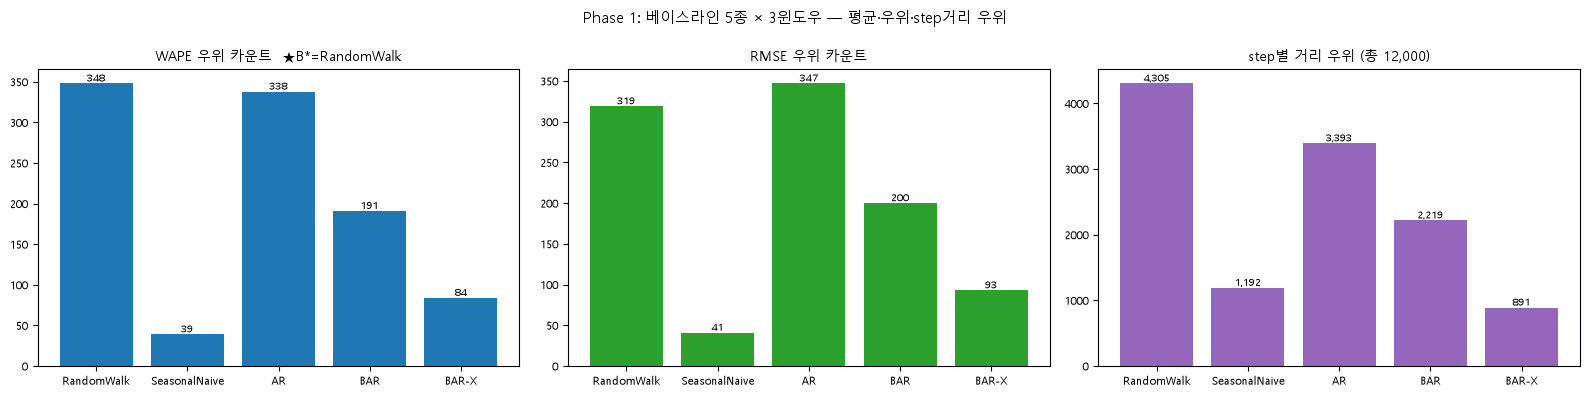

In [46]:
# ===== Phase 1: KB50 × 3 롤링 윈도우 베이스라인 5종 평가 → B* 선정 =====
GROUP_KEYS = ["Header_구", "Header_동", "Header_단지명", "Header_평형"]
_BASE_DIR = log_dir("baseline")


def evaluate_baselines_windows(panel: pd.DataFrame):
    """KB50 단지×평형 × 3윈도우. 각 윈도우: 8년 train 적합 → 24개월 단일원점 예측 → RMSE/WAPE.
    동시에 모든 step(월)에서 5종 중 실제값과 가장 가까운 모델(거리우위)을 카운트.
    반환: (long_df[윈도우·단지·모델·RMSE·WAPE], stepwise_wins{모델:점수}, total_steps, n_groups)."""
    rows = []
    stepwise_wins = {m: 0 for m in BASELINE_MODELS}
    total_steps = 0
    n_groups = 0
    BT = CFG.HORIZON
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL)
        t = g[CFG.TIME_COL]
        gid = "|".join(str(x) for x in keyvals)
        for w in BT_WINDOWS:
            tr = g[(t >= w["tr_start"]) & (t <= w["tr_end"])]
            bt = g[(t >= w["bt_start"]) & (t <= w["bt_end"])]
            ytr = tr[CFG.TARGET_COL].astype(float).values
            ybt = bt[CFG.TARGET_COL].astype(float).values
            if len(tr) < CFG.MIN_TRAIN_MONTHS or len(bt) < BT:
                continue
            if np.any(ytr <= 0) or np.any(ybt <= 0):
                continue
            z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
            exog_tr = get_exog_array(tr)
            y_true = ybt[:BT]
            try:
                p_star = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0]
            except Exception:
                p_star = 1
            preds = {}
            for m in BASELINE_MODELS:
                try:
                    zp = base_forecast_log(m, z_tr, BT, exog_tr=exog_tr, p_ar=p_star)
                except Exception:
                    continue
                yp = to_price_space(zp)
                preds[m] = yp
                rows.append({"윈도우": w["name"], "단지": gid, "모델": m,
                             "RMSE": rmse(y_true, yp), "WAPE": wape(y_true, yp)})
            # --- step별 거리 우위: 각 월에서 |실제-예측| 최소 모델 +1 ---
            if len(preds) == len(BASELINE_MODELS):
                dist = np.vstack([np.abs(y_true - preds[m]) for m in BASELINE_MODELS])  # (5, 24)
                winners = np.argmin(dist, axis=0)
                for wi in winners:
                    stepwise_wins[BASELINE_MODELS[wi]] += 1
                total_steps += len(y_true)
    return pd.DataFrame(rows), stepwise_wins, total_steps, n_groups


def win_counts_keyed(df_long, metric, keys):
    wins = {}
    for _, gg in df_long.groupby(keys):
        w = gg.loc[gg[metric].idxmin(), "모델"]
        wins[w] = wins.get(w, 0) + 1
    return wins


# 베이스라인 평가는 stepwise 집계를 위해 항상 새로 계산(결과 long df는 캐시 저장).
base_df, stepwise_wins, total_steps, _ng = evaluate_baselines_windows(kb50_panel)
base_df.to_csv(os.path.join(_BASE_DIR, "baseline_windows_kb50.csv"), index=False, encoding="utf-8-sig")
print(f"[phase1] {_ng:,}개 단지·평형 × 3윈도우 평가 완료 → {len(base_df):,}행")

# --- (1) 전체 평균 RMSE·WAPE ---
_finite = base_df.replace([np.inf, -np.inf], np.nan)
avg_table = _finite.groupby("모델")[["RMSE", "WAPE"]].mean().reindex(BASELINE_MODELS)
n_cases = base_df.groupby(["윈도우", "단지"]).ngroups
print(f"\n=== (1) 분석 매물 전체 평균 RMSE·WAPE (총 {n_cases:,} 윈도우×단지·평형) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  평균RMSE {avg_table.loc[m,'RMSE']:>12,.1f}   평균WAPE {avg_table.loc[m,'WAPE']:>8.4f}")

# --- (2) 우위 카운트 (WAPE·RMSE) ---
wins_wape = win_counts_keyed(base_df, "WAPE", ["윈도우", "단지"])
wins_rmse = win_counts_keyed(base_df, "RMSE", ["윈도우", "단지"])
print(f"\n=== (2) 우위 카운트 (윈도우×단지·평형 조합별 승자, 총 {n_cases:,}) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  WAPE우위 {wins_wape.get(m,0):>5,} ({wins_wape.get(m,0)/n_cases:5.1%})   "
          f"RMSE우위 {wins_rmse.get(m,0):>5,} ({wins_rmse.get(m,0)/n_cases:5.1%})")

# --- (3) step별 거리 우위 ---
print(f"\n=== (3) step별 거리 우위 (모든 분석의 모든 월에서 실제값 최근접 모델, 총 {total_steps:,} step) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  {stepwise_wins.get(m,0):>7,} step ({stepwise_wins.get(m,0)/max(total_steps,1):5.1%})")

# --- B* 선정: WAPE 우위 카운트 최다 (동률 → 평균 WAPE 낮은 쪽) ---
B_STAR = max(BASELINE_MODELS, key=lambda m: (wins_wape.get(m, 0), -avg_table.loc[m, "WAPE"]))
print(f"\n[phase1] ★ B* (WAPE 우위 최다) = {B_STAR}")

# --- 로그 저장 ---
avg_table.to_csv(os.path.join(_BASE_DIR, "baseline_avg_metrics.csv"), encoding="utf-8-sig")
pd.DataFrame({"모델": BASELINE_MODELS,
              "WAPE우위": [wins_wape.get(m, 0) for m in BASELINE_MODELS],
              "RMSE우위": [wins_rmse.get(m, 0) for m in BASELINE_MODELS],
              "step거리우위": [stepwise_wins.get(m, 0) for m in BASELINE_MODELS]}).to_csv(
    os.path.join(_BASE_DIR, "baseline_win_counts.csv"), index=False, encoding="utf-8-sig")
with open(os.path.join(_BASE_DIR, "baseline_selection.log"), "w", encoding="utf-8") as _f:
    _f.write(f"[Phase 1] 베이스라인 선정 — KB50 × 3 롤링 윈도우 (총 {n_cases:,} 분석)\n")
    for w in BT_WINDOWS:
        _f.write(f"  {w['name']}: {w['label']}\n")
    _f.write("=" * 70 + "\n(1) 평균 지표\n")
    _f.write(avg_table.round(4).to_string() + "\n\n(2) 우위 카운트\n")
    for m in BASELINE_MODELS:
        _f.write(f"  {m:14s} WAPE우위 {wins_wape.get(m,0)} | RMSE우위 {wins_rmse.get(m,0)}\n")
    _f.write(f"\n(3) step거리우위 (총 {total_steps:,} step)\n")
    for m in BASELINE_MODELS:
        _f.write(f"  {m:14s} {stepwise_wins.get(m,0)} step\n")
    _f.write(f"\n★ B* = {B_STAR}\n")
print(f"[phase1] 로그 저장: {_BASE_DIR}")

# --- 시각화 ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(BASELINE_MODELS, [wins_wape.get(m, 0) for m in BASELINE_MODELS], color="tab:blue")
ax[0].set_title(f"WAPE 우위 카운트  ★B*={B_STAR}", fontsize=10)
ax[1].bar(BASELINE_MODELS, [wins_rmse.get(m, 0) for m in BASELINE_MODELS], color="tab:green")
ax[1].set_title("RMSE 우위 카운트", fontsize=10)
ax[2].bar(BASELINE_MODELS, [stepwise_wins.get(m, 0) for m in BASELINE_MODELS], color="tab:purple")
ax[2].set_title(f"step별 거리 우위 (총 {total_steps:,})", fontsize=10)
for a in ax:
    a.tick_params(labelsize=8)
    for r in a.patches:
        a.text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(r.get_height()):,}",
               ha="center", va="bottom", fontsize=7)
plt.suptitle("Phase 1: 베이스라인 5종 × 3윈도우 — 평균·우위·step거리 우위", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(_BASE_DIR, "baseline_selection.png"), dpi=110, bbox_inches="tight")
plt.show()


# Phase 2. B\* 잔차를 CatBoost 로 학습 — **보유 데이터 전체(meta_ml)**

선정된 **B\*** 의 **h스텝 예측오차**를 전역 패널(meta_ml 전체 단지×평형)로 회귀한다.
(배포용 모델은 보유 데이터 전체에 학습. Phase 3 검증은 누수 차단을 위해 윈도우별로 별도 재학습한다.)

## 왜 1스텝 잔차가 아니라 h스텝 예측오차인가
1스텝 in-sample 잔차는 정의상 백색화되어 거시·정적 피처로 설명되지 않는다. 대신 원점 $t_0$ 에서 미래거시를 모른 채
외삽한 **h스텝 예측오차**를 타깃으로 쓴다 — "예측 후 실현된 거시"가 그 오차(드리프트)를 설명할 수 있어 **진짜 신호**가 생긴다.

$$e^{(c)}_{t_0,h}=\log P^{(c)}_{t_0+h}-\widehat{\log P^{(c)}_{t_0+h}}\Big|_{B^{*}\text{ from }t_0}$$

- **피처** : ① 실현시점 $t_0+h$ 의 거시(D1/D2/D3)+단지 Static, ② 원점추세 `ORIGIN_FEATS`
  $=\{\text{base\_drift}_h,\text{origin\_last},\text{origin\_mom}_{3/6/12}\}$ + 예측지평 $h$.
  - $\text{base\_drift}_h=\widehat{\log P}_{t_0+h}-\log P_{t_0-1}$ (B\* 외삽 변화량), $\text{origin\_mom}_k=\log P_{t_0-1}-\log P_{t_0-1-k}$.
- **원점추세를 넣는 이유** : 오차의 *방향*은 "B\* 가 무엇을 예측했는가"에 달려 있다. 레짐 전환 구간에서 train/valid 오차 부호가
  뒤집히는 것을 `base_drift` 등으로 고정한다. 모두 원점 기지값 → **누수 없음**(추론에서 동일 재현).

## CatBoost
$$\widehat e_t=f_{\text{CatBoost}}\big(\underbrace{\text{Static}}_{\text{건설사, 평수, 세대수, 초품아}},\underbrace{D1,D2,D3}_{\text{거시, 권역, 구별}},\,h,\,\text{원점추세}\big)$$
- categorical=`Static__*`(역세권수·호재수 제외), numeric=`depth1/2/3`+카운트+`h`+원점추세.
- 시간기반 hold-out(마지막 12개월)로 early stopping → 과적합 방지. 손실=RMSE(로그공간 대칭).
- 하이퍼파라미터는 `CFG.CB_*`(Phase 3 튜닝 반영).


In [47]:
# ===== Phase 2-A. 피처 정의 + h스텝 오차 학습세트 빌더 =====
HSTEP_COL = "h_step"
ORIGIN_FEATS = ["base_drift", "origin_last", "origin_mom3", "origin_mom6", "origin_mom12"]


def split_features(columns: List[str]) -> Tuple[List[str], List[str]]:
    num, cat = feature_columns(columns)
    cat_final = [c for c in cat if c not in STATIC_NUMERIC_HINT]
    num_final = num + [c for c in cat if c in STATIC_NUMERIC_HINT]
    return num_final, cat_final


_num0, CAT_FEATS = split_features(list(kb50_panel.columns))
NUM_FEATS = _num0 + ([HSTEP_COL] if CFG.INCLUDE_HSTEP_FEATURE else []) + ORIGIN_FEATS
print(f"[feat] 수치피처 {len(NUM_FEATS)}개  | 범주피처 {len(CAT_FEATS)}개: {CAT_FEATS}")


def build_hstep_trainset(panel: pd.DataFrame, b_star: str) -> pd.DataFrame:
    """패널 각 단지×평형에서 롤링 원점 B* → h스텝 예측오차를 타깃으로. 피처=실현시점 거시/정적+h_step+원점추세."""
    out_frames = []
    n_groups = n_used = 0
    H = CFG.HORIZON
    for _, g in panel.groupby(GROUP_KEYS, sort=False):
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL).reset_index(drop=True)
        y = g[CFG.TARGET_COL].astype(float).values
        n = len(g)
        if n < CFG.MIN_TRAIN_MONTHS + 1 or np.any(y <= 0):
            continue
        z = np.log(y) if CFG.LOG_TARGET else y
        Xex_g = get_exog_array(g)
        p_c = fit_select_ar(z, CFG.PANEL_AR_MAX_LAG, CFG.AR_IC)[0] if b_star == "AR" else None
        used_this = False
        for t0 in range(CFG.MIN_TRAIN_MONTHS, n - 1, CFG.ORIGIN_STRIDE):
            z_tr = z[:t0]
            hmax = min(H, n - 1 - t0)
            if hmax < 1:
                continue
            try:
                fc = base_forecast_log(b_star, z_tr, hmax, exog_tr=Xex_g[:t0], p_ar=p_c)
            except Exception:
                continue
            fc = np.asarray(fc, float)
            if not np.all(np.isfinite(fc)):
                continue
            if np.max(np.abs(fc - z_tr[-1])) > CFG.AR_FORECAST_GUARD:
                continue
            idx_future = np.arange(t0, t0 + hmax)
            err = z[idx_future] - fc
            drift = fc - z_tr[-1]
            keep = np.abs(err) <= CFG.ERR_CLIP_LOG
            if not np.any(keep):
                continue
            idx_future, err, drift = idx_future[keep], err[keep], drift[keep]
            rows = g.iloc[idx_future].copy()
            rows[HSTEP_COL] = (idx_future - t0 + 1)
            rows["resid_target"] = err
            last = z_tr[-1]
            rows["base_drift"]   = drift
            rows["origin_last"]  = last
            rows["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
            rows["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
            rows["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
            out_frames.append(rows)
            used_this = True
        if used_this:
            n_used += 1
    res_df = pd.concat(out_frames, ignore_index=True) if out_frames else pd.DataFrame()
    print(f"    [resid] B*={b_star} | 그룹 {n_groups:,}개 중 {n_used:,}개 사용 → h스텝 오차샘플 {len(res_df):,}")
    return res_df


def _prep_features(df: pd.DataFrame) -> pd.DataFrame:
    """CatBoost 입력 정리: categorical=문자열+결측'NA', numeric=float."""
    X = df[NUM_FEATS + CAT_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = X[c].astype("object").where(X[c].notna(), "NA").astype(str)
    for c in NUM_FEATS:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


def make_catboost() -> CatBoostRegressor:
    """현재 CFG.CB_* 로 CatBoostRegressor 생성 (Phase 3 튜닝과 공유)."""
    return CatBoostRegressor(
        iterations=CFG.CB_ITERATIONS, learning_rate=CFG.CB_LEARNING_RATE, depth=CFG.CB_DEPTH,
        l2_leaf_reg=CFG.CB_L2_LEAF_REG, border_count=CFG.CB_BORDER_COUNT,
        bagging_temperature=CFG.CB_BAGGING_TEMPERATURE, random_strength=CFG.CB_RANDOM_STRENGTH,
        loss_function="RMSE", random_seed=CFG.CB_RANDOM_SEED, task_type=CATBOOST_TASK_TYPE,
        od_type="Iter", od_wait=CFG.CB_EARLY_STOP, verbose=False)


def train_catboost(ts: pd.DataFrame, verbose=False):
    """h스텝 학습세트 → 시간기반 hold-out(마지막 12개월) early stopping → (모델, X_va, y_va, mask)."""
    _cut = ts[CFG.TIME_COL].max() - pd.DateOffset(months=12)
    m = ts[CFG.TIME_COL] <= _cut
    Xtr = _prep_features(ts[m]);  ytr = ts.loc[m, "resid_target"].values
    Xva = _prep_features(ts[~m]); yva = ts.loc[~m, "resid_target"].values
    ci = [Xtr.columns.get_loc(c) for c in CAT_FEATS]
    cb = make_catboost()
    if verbose:
        cb.set_params(verbose=200)
    cb.fit(Pool(Xtr, ytr, cat_features=ci), eval_set=Pool(Xva, yva, cat_features=ci), use_best_model=True)
    return cb, Xva, yva, ~m


print("[phase2] 빌더 준비: build_hstep_trainset, _prep_features, make_catboost, train_catboost")


[feat] 수치피처 24개  | 범주피처 5개: ['Static__준공구분', 'Static__세대수구분', 'Static__평수구분', 'Static__건설사등급', 'Static__초품아여부']
[phase2] 빌더 준비: build_hstep_trainset, _prep_features, make_catboost, train_catboost


In [ ]:
# ===== Phase 2-B. 배포용 CatBoost — 보유 데이터 전체(meta_ml) 학습 =====
_bstar_tag = B_STAR.replace("-", "").replace("/", "")
_CB_DIR = log_dir(f"{_bstar_tag}_catboost")

# (1) 보유 데이터 전체 패널(컷오프 없음 ≈ 2026-05까지) 적재·캐시
_full_cache = os.path.join(log_dir("module0_cache"), "global_panel_full.pkl")
if os.path.exists(_full_cache):
    panel_all = pd.read_pickle(_full_cache)
    print(f"[phase2] 전체 패널 캐시 로드: {panel_all.shape[0]:,}행")
else:
    panel_all = load_global_panel("2099-12-01")   # 사실상 전체
    panel_all.to_pickle(_full_cache)
    print(f"[phase2] 전체 패널 적재·캐시: {panel_all.shape[0]:,}행")
print(f"[phase2] 전체 패널 기간: {panel_all[CFG.TIME_COL].min().date()} ~ {panel_all[CFG.TIME_COL].max().date()}")

# (2) B* h스텝 오차 학습세트(전체 데이터)
print(f"[phase2] B*={B_STAR} h스텝 오차 학습세트 빌드(전체 데이터)…")
resid_train = build_hstep_trainset(panel_all, B_STAR)
resid_train.to_pickle(os.path.join(_CB_DIR, f"hstep_trainset_{_bstar_tag}_full.pkl"))
print(f"[phase2] 학습세트: {resid_train.shape[0]:,}행 × {resid_train.shape[1]}열  "
      f"오차 mean={resid_train['resid_target'].mean():+.5f} std={resid_train['resid_target'].std():.5f}")

# (3) CatBoost 학습(시간기반 hold-out early stopping) → 배포 모델
cb_model, X_va, y_va, va_mask = train_catboost(resid_train, verbose=True)
tr_mask = ~va_mask
X_tr = _prep_features(resid_train[tr_mask]); y_tr = resid_train.loc[tr_mask, "resid_target"].values
cat_idx = [X_tr.columns.get_loc(c) for c in CAT_FEATS]
cb_model.save_model(os.path.join(_CB_DIR, f"catboost_residual_{_bstar_tag}_full.cbm"))

_pred_va = cb_model.predict(X_va)
_zero_rmse = float(np.sqrt(np.mean(np.square(y_va))))
print(f"\n[phase2] 배포 CatBoost  best_iter={cb_model.get_best_iteration()}")
print(f"[phase2] valid 잔차 RMSE: 무보정={_zero_rmse:.5f}  CatBoost={rmse(y_va, _pred_va):.5f}  "
      f"(이득 {_zero_rmse - rmse(y_va, _pred_va):+.5f})")
with open(os.path.join(_CB_DIR, "train.log"), "w", encoding="utf-8") as _f:
    _f.write(f"[Phase 2] 배포 CatBoost (B*={B_STAR}, 보유 데이터 전체)\n")
    _f.write(f"학습세트 {len(resid_train):,}행 | best_iter={cb_model.get_best_iteration()}\n")
    _f.write(f"params: iter={CFG.CB_ITERATIONS} lr={CFG.CB_LEARNING_RATE} depth={CFG.CB_DEPTH} "
             f"l2={CFG.CB_L2_LEAF_REG} border={CFG.CB_BORDER_COUNT} "
             f"bag_temp={CFG.CB_BAGGING_TEMPERATURE} rand_str={CFG.CB_RANDOM_STRENGTH}\n")
    _f.write(f"valid RMSE 무보정={_zero_rmse:.5f} CatBoost={rmse(y_va, _pred_va):.5f}\n")
print(f"[phase2] 모델·로그 저장: {_CB_DIR}")


[phase2] 전체 패널 캐시 로드: 2,046,245행
[phase2] 전체 패널 기간: 2010-01-01 ~ 2026-05-01
[phase2] B*=RandomWalk h스텝 오차 학습세트 빌드(전체 데이터)…


# Phase 3. `B*` vs `B* + CatBoost` 검증 (3 롤링 윈도우) 

KB50 단지·평형 **전체**를 3 롤링 윈도우에서 **중심선(점예측)** 으로 비교한다.

- **Before** = B\* 점예측. **After** = B\* + CatBoost 잔차보정(예측구간 실현거시를 피처로 쓰는 조건부 보정).
- **누수 차단** : 각 윈도우마다 그 `tr_end` 이하 전역패널로 h스텝 학습세트를 **재구성·재학습**한 CatBoost 만 사용 →
  과거 윈도우(2022·2023)에서도 After 가 미래를 보지 않는다. (Before 는 윈도우별 재적합이라 항상 정직)

세 가지 리포트(분석 매물 전체) : ① 평균 WAPE·RMSE, ② WAPE·RMSE 우위 카운트, ③ step별 거리 우위.


In [ ]:
# ===== Phase 3-A. precompute: 윈도우별 h스텝 학습세트 + KB50 B* 점예측·피처(파라미터 무관) =====
_VS_DIR = log_dir(f"{_bstar_tag}_vs_catboost")
_TARGET, _TIME = CFG.TARGET_COL, CFG.TIME_COL


def build_window_trainset(tr_end):
    """tr_end 이하 전역 패널 → h스텝 학습세트(캐시). 누수 없음."""
    cache = os.path.join(_VS_DIR, f"hstep_trainset_{_bstar_tag}_{tr_end:%Y-%m}.pkl")
    if os.path.exists(cache):
        ts = pd.read_pickle(cache)
        print(f"    [resid] 캐시 로드 ≤{tr_end:%Y-%m}: {len(ts):,}행")
        return ts
    sub = panel_full[panel_full[_TIME] <= tr_end]
    ts = build_hstep_trainset(sub, B_STAR)
    ts.to_pickle(cache)
    return ts


def precompute_kb50_window(panel, w):
    """KB50 각 단지×평형: 윈도우 w의 B* 점예측 + CatBoost 입력 피처행렬(준비완료) + 실제값 + Before가격.
    파라미터 무관 → 튜닝 시 cb.predict 만 반복하면 됨."""
    H = CFG.HORIZON
    tr_lo, tr_hi = w["tr_start"], w["tr_end"]
    te_lo, te_hi = w["bt_start"], w["bt_end"]
    items = []
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        g = g.sort_values(_TIME).reset_index(drop=True)
        t = g[_TIME]
        tr = g[(t >= tr_lo) & (t <= tr_hi)]
        te = g[(t >= te_lo) & (t <= te_hi)].head(H)
        ytr = tr[_TARGET].astype(float).values
        yte = te[_TARGET].astype(float).values
        if len(tr) < CFG.MIN_TRAIN_MONTHS or len(te) < H or np.any(ytr <= 0) or np.any(yte <= 0):
            continue
        z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
        last = z_tr[-1]
        exog_tr = get_exog_array(tr)
        try:
            p_c = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0] if B_STAR == "AR" else None
            base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)
        except Exception:
            continue
        if not np.all(np.isfinite(base_log)):
            continue
        feat = te.copy()
        feat[HSTEP_COL]      = np.arange(1, H + 1)
        feat["base_drift"]   = base_log - last
        feat["origin_last"]  = last
        feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
        feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
        feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
        items.append({
            "윈도우": w["name"], "단지": "|".join(str(x) for x in keyvals),
            "Xprep": _prep_features(feat), "base_log": base_log, "last": last,
            "yte": yte, "dates": pd.to_datetime(te[_TIME].values),
            "before_price": to_price_space(base_log),
        })
    return items


WIN_TRAINSETS = {}
WIN_KB50 = {}
for w in BT_WINDOWS:
    print(f"[phase3-A] {w['name']}  {w['label']}")
    WIN_TRAINSETS[w["name"]] = build_window_trainset(w["tr_end"])
    WIN_KB50[w["name"]] = precompute_kb50_window(kb50_panel, w)
    print(f"    → KB50 분석 케이스 {len(WIN_KB50[w['name']]):,}개")

# Before(점예측) 지표 — 파라미터 무관, 1회 산출
_n_total = sum(len(v) for v in WIN_KB50.values())
before_wape = np.mean([wape(it["yte"], it["before_price"])
                       for v in WIN_KB50.values() for it in v])
before_rmse = np.mean([rmse(it["yte"], it["before_price"])
                       for v in WIN_KB50.values() for it in v])
print(f"\n[phase3-A] 분석 케이스 총 {_n_total:,}개  |  Before({B_STAR}) 평균 WAPE={before_wape:.4f}  RMSE={before_rmse:,.1f}")
_FEAT_ORDER = NUM_FEATS + CAT_FEATS
cat_idx = [_FEAT_ORDER.index(c) for c in CAT_FEATS]


[phase3-A] BT@2024-06  2016-06~2024-05 → 2024-06~2026-05
    [resid] B*=AR | 그룹 10,795개 중 10,374개 사용 → h스텝 오차샘플 2,582,880
    → KB50 분석 케이스 346개
[phase3-A] BT@2023-06  2015-06~2023-05 → 2023-06~2025-05
    [resid] B*=AR | 그룹 10,596개 중 10,267개 사용 → h스텝 오차샘플 2,314,152
    → KB50 분석 케이스 334개
[phase3-A] BT@2022-06  2014-06~2022-05 → 2022-06~2024-05
    [resid] B*=AR | 그룹 10,508개 중 10,113개 사용 → h스텝 오차샘플 2,050,106
    → KB50 분석 케이스 320개

[phase3-A] 분석 케이스 총 1,000개  |  Before(AR) 평균 WAPE=0.1399  RMSE=60,982.6


① 분석 매물 전체 평균 점예측 지표
  지표  Before(AR)  After(AR+CB)    개선율
WAPE      0.1399        0.1246 0.1094
RMSE 60,982.5550   49,377.9104 0.1903

② 분석 단위 우위 카운트 (총 1,000개 분석)
  기준  After 우위  Before 우위  동점  After 승률
WAPE       519        481   0     0.519
RMSE       555        445   0     0.555

③ step별 거리 우위 (총 24,000 step = 분석수 × 24)
          구분  우위 step 수    비율
After(AR+CB)      11609 0.484
  Before(AR)      12391 0.516
          동점          0 0.000


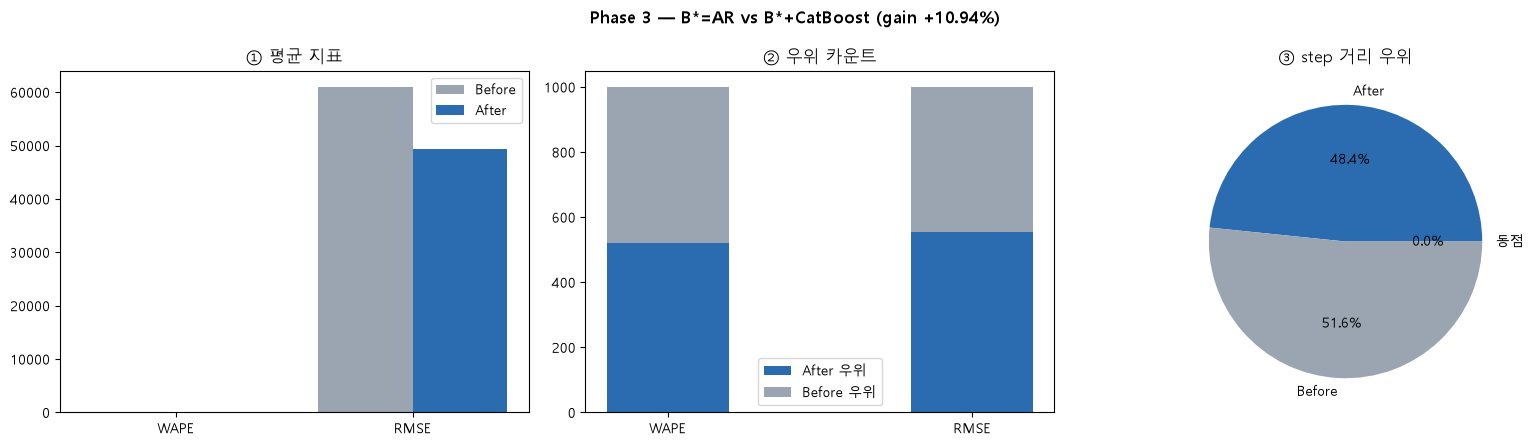


[phase3-C] 저장 완료: C:\Users\equip\Desktop\newtrial\ml_pipeline\final\output\AR_vs_catboost


In [ ]:
# ===== Phase 3-C. 리포트: ①평균 WAPE·RMSE ②우위 카운트 ③step 거리우위 + 시각화·로그 =====
# ① 평균 지표
avg_ba = pd.DataFrame({
    "지표": ["WAPE", "RMSE"],
    f"Before({B_STAR})": [vs_summ["wape_before"], vs_summ["rmse_before"]],
    f"After({B_STAR}+CB)": [vs_summ["wape_after"], vs_summ["rmse_after"]],
})
avg_ba["개선율"] = 1.0 - avg_ba[f"After({B_STAR}+CB)"] / avg_ba[f"Before({B_STAR})"]
print("① 분석 매물 전체 평균 점예측 지표")
print(avg_ba.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

# ② 우위 카운트(분석 단위로 더 낮은 쪽 승)
w_wape_after  = int((vs_df["WAPE_After"]  < vs_df["WAPE_Before"]).sum())
w_wape_before = int((vs_df["WAPE_Before"] < vs_df["WAPE_After"]).sum())
w_rmse_after  = int((vs_df["RMSE_After"]  < vs_df["RMSE_Before"]).sum())
w_rmse_before = int((vs_df["RMSE_Before"] < vs_df["RMSE_After"]).sum())
n = len(vs_df)
win_ba = pd.DataFrame({
    "기준": ["WAPE", "RMSE"],
    f"After 우위": [w_wape_after, w_rmse_after],
    f"Before 우위": [w_wape_before, w_rmse_before],
    "동점": [n - w_wape_after - w_wape_before, n - w_rmse_after - w_rmse_before],
    "After 승률": [w_wape_after / n, w_rmse_after / n],
})
print(f"\n② 분석 단위 우위 카운트 (총 {n:,}개 분석)")
print(win_ba.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# ③ step별 거리 우위
sw = pd.DataFrame({
    "구분": [f"After({B_STAR}+CB)", f"Before({B_STAR})", "동점"],
    "우위 step 수": [vs_summ["sw_after"], vs_summ["sw_before"], vs_summ["sw_tie"]],
})
sw["비율"] = sw["우위 step 수"] / vs_summ["sw_total"]
print(f"\n③ step별 거리 우위 (총 {vs_summ['sw_total']:,} step = 분석수 × {CFG.HORIZON})")
print(sw.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# 로그 저장
avg_ba.to_csv(os.path.join(_VS_DIR, "avg_metrics.csv"), index=False, encoding="utf-8-sig")
win_ba.to_csv(os.path.join(_VS_DIR, "win_counts.csv"), index=False, encoding="utf-8-sig")
sw.to_csv(os.path.join(_VS_DIR, "stepwise_distance_wins.csv"), index=False, encoding="utf-8-sig")
vs_df.to_csv(os.path.join(_VS_DIR, "per_analysis_before_after.csv"), index=False, encoding="utf-8-sig")
for nm, cb in CB_BY_WINDOW.items():
    cb.save_model(os.path.join(_VS_DIR, f"catboost_{_bstar_tag}_{nm}.cbm"))
with open(os.path.join(_VS_DIR, "summary.log"), "w", encoding="utf-8") as f:
    f.write(f"[Phase 3] B*={B_STAR} vs B*+CatBoost (3 롤링 윈도우)\n")
    f.write(f"확정 CatBoost: {_best['params']}\n")
    f.write(f"평균 WAPE: Before={vs_summ['wape_before']:.4f} After={vs_summ['wape_after']:.4f} "
            f"(gain {_best['gain']:+.2%})\n")
    f.write(f"평균 RMSE: Before={vs_summ['rmse_before']:,.1f} After={vs_summ['rmse_after']:,.1f}\n")
    f.write(f"WAPE 우위: After={w_wape_after} Before={w_wape_before} / RMSE 우위: After={w_rmse_after} Before={w_rmse_before}\n")
    f.write(f"step 거리우위: After={vs_summ['sw_after']} Before={vs_summ['sw_before']} 동점={vs_summ['sw_tie']}\n")

# 시각화
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
xb = np.arange(2)
ax[0].bar(xb - 0.2, avg_ba[f"Before({B_STAR})"], 0.4, label="Before", color="#9aa5b1")
ax[0].bar(xb + 0.2, avg_ba[f"After({B_STAR}+CB)"], 0.4, label="After", color="#2b6cb0")
ax[0].set_xticks(xb); ax[0].set_xticklabels(["WAPE", "RMSE"]); ax[0].set_title("① 평균 지표"); ax[0].legend()
ax[1].bar(["WAPE", "RMSE"], [w_wape_after, w_rmse_after], 0.4, color="#2b6cb0", label="After 우위")
ax[1].bar(["WAPE", "RMSE"], [w_wape_before, w_rmse_before], 0.4,
          bottom=[w_wape_after, w_rmse_after], color="#9aa5b1", label="Before 우위")
ax[1].set_title("② 우위 카운트"); ax[1].legend()
ax[2].pie([vs_summ["sw_after"], vs_summ["sw_before"], vs_summ["sw_tie"]],
          labels=["After", "Before", "동점"], autopct="%1.1f%%",
          colors=["#2b6cb0", "#9aa5b1", "#e2e8f0"])
ax[2].set_title("③ step 거리 우위")
fig.suptitle(f"Phase 3 — B*={B_STAR} vs B*+CatBoost (gain {_best['gain']:+.2%})", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(_VS_DIR, "phase3_compare.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase3-C] 저장 완료: {_VS_DIR}")


# Phase 4. SHAP 해석 — 구별 500 표본 × 25구 = 12,500 포인트

배포 CatBoost(`cb_model`, 보유 데이터 전체 학습, **확정 튜닝 파라미터**)의 잔차보정 기여를 SHAP 로 분해한다.

- **층화 표본** : 각 구에서 학습세트(`resid_train`) 중 **500행 무작위 표본** → 25구 × 500 = **12,500 포인트**
  (구별 표본수가 500 미만이면 가용 전량). 구 단위 균형 표본이라 특정 대형 구가 해석을 지배하지 않는다.
- **SHAP 값** : $\phi_{ij}$ = 표본 $i$ 의 피처 $j$ 가 예측 잔차보정에 더한 기여(로그수익률 단위, 가법 분해)
  $$\hat{r}_i=\phi_0+\sum_j \phi_{ij}$$
- **전역 중요도** : $\bar{\phi}_j=\frac{1}{N}\sum_i|\phi_{ij}|$ (평균 절대 기여).
- **경제적 해석** : 거시(금리·M2·CPI), 공급–수요(REB), 가격지수(KB·REB), 정책(LTV·DSR·규제), 원점추세(모멘텀)가
  B\* 점예측의 **체계적 편의를 어떻게 보정**하는지 가시화.


[phase4] 확정 파라미터로 배포 CatBoost 재학습: {'CB_ITERATIONS': 3000, 'CB_LEARNING_RATE': 0.03, 'CB_DEPTH': 8, 'CB_L2_LEAF_REG': 3.0, 'CB_RANDOM_STRENGTH': 1.0, 'CB_BAGGING_TEMPERATURE': 1.0, 'CB_BORDER_COUNT': 254}
[phase4] 재학습 완료 best_iter=1160
[phase4] 표본 12,500행 / 25구 (구당 500~500, 목표 500)

[phase4] base value φ0=-0.02845
[phase4] 전역 중요도 Top 15:
                            feature  mean_abs_shap
                         base_drift        0.08673
                             h_step        0.01489
                        origin_last        0.01401
          depth1__ecos__cd_91d_rate        0.01175
      depth3__policy__ltv_tightness        0.01072
                       origin_mom12        0.00989
        depth3__reb__apt_sale_index        0.00942
               depth1__ecos__m2_avg        0.00840
      depth3__reb__apt_jeonse_index        0.00777
            depth1__ecos__base_rate        0.00642
          depth1__ecos__cpi_housing        0.00548
                        origin_mom6        0.004

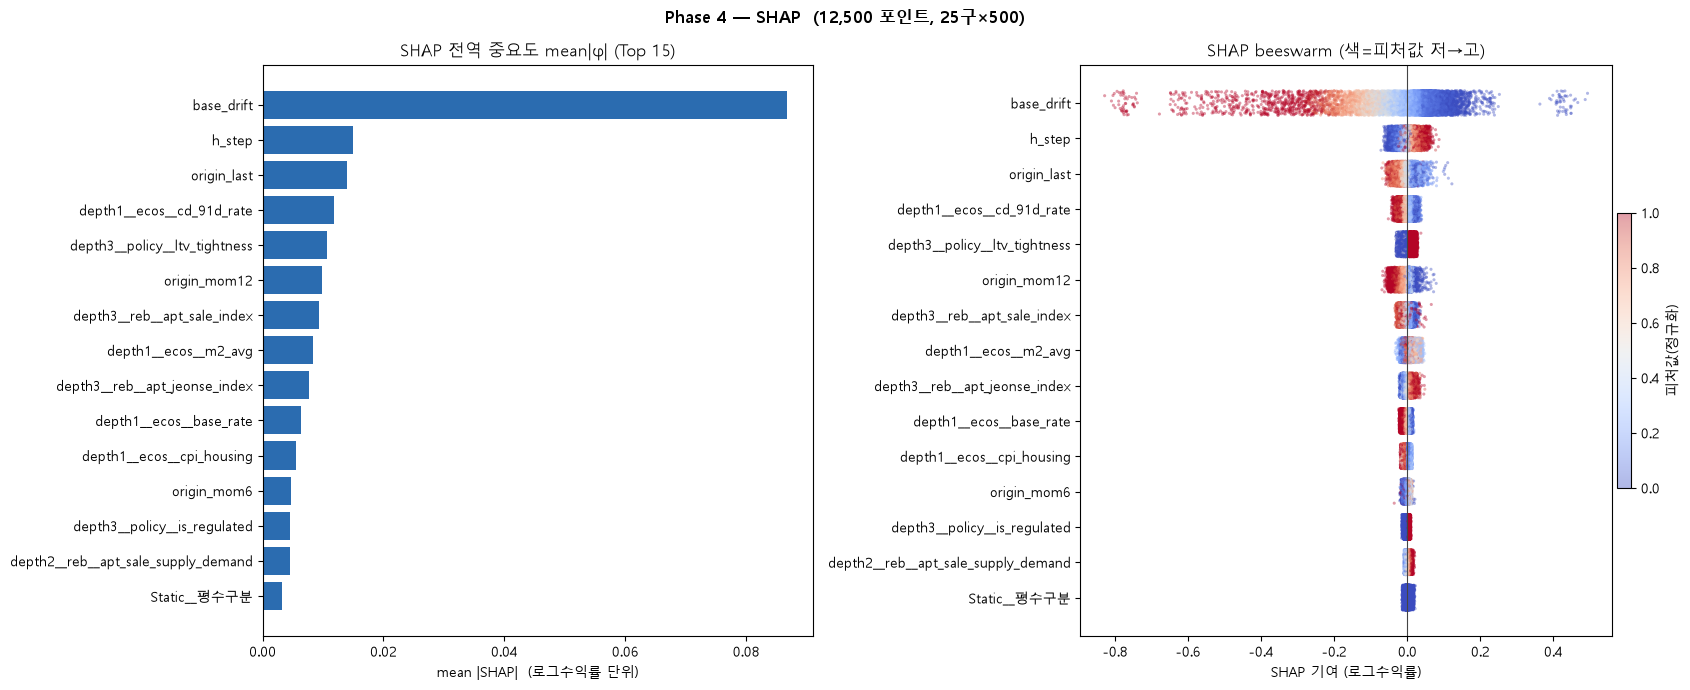


[phase4] 저장 완료: C:\Users\equip\Desktop\newtrial\ml_pipeline\final\output\AR_shap


In [ ]:
# ===== Phase 4. SHAP — 구별 500 × 25구 = 12,500 포인트 =====
_SHAP_DIR = log_dir(f"{_bstar_tag}_shap")

# (0) 배포 모델을 Phase3 확정 파라미터로 재학습(일관성 보장) → cb_model 갱신
print(f"[phase4] 확정 파라미터로 배포 CatBoost 재학습: {_best['params']}")
cb_model, X_va, y_va, va_mask = train_catboost(resid_train, verbose=False)
cb_model.save_model(os.path.join(_CB_DIR, f"catboost_residual_{_bstar_tag}_full.cbm"))
print(f"[phase4] 재학습 완료 best_iter={cb_model.get_best_iteration()}")

# (1) 구별 층화 표본 500 × 25구
rng = np.random.default_rng(CFG.CB_RANDOM_SEED)
per_gu = CFG.SHAP_PER_GU
parts = []
for gu, idx in resid_train.groupby("Header_구").groups.items():
    idx = np.asarray(list(idx))
    take = idx if len(idx) <= per_gu else rng.choice(idx, per_gu, replace=False)
    parts.append(resid_train.loc[take])
shap_sample = pd.concat(parts).reset_index(drop=True)
gu_counts = shap_sample["Header_구"].value_counts().sort_index()
print(f"[phase4] 표본 {len(shap_sample):,}행 / {gu_counts.size}구 "
      f"(구당 {gu_counts.min()}~{gu_counts.max()}, 목표 {per_gu})")

# (2) SHAP 값 산출
X_shap = _prep_features(shap_sample)
shap_pool = Pool(X_shap, cat_features=cat_idx)
shap_vals = cb_model.get_feature_importance(shap_pool, type="ShapValues")  # (N, F+1)
phi0 = float(shap_vals[0, -1])
phi = shap_vals[:, :-1]
feat_names = list(X_shap.columns)

# (3) 전역 중요도 mean|phi|
imp = (pd.DataFrame({"feature": feat_names, "mean_abs_shap": np.abs(phi).mean(0)})
       .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
imp.to_csv(os.path.join(_SHAP_DIR, "global_importance.csv"), index=False, encoding="utf-8-sig")
gu_counts.to_csv(os.path.join(_SHAP_DIR, "gu_sample_counts.csv"), encoding="utf-8-sig")
np.save(os.path.join(_SHAP_DIR, "shap_values.npy"), shap_vals)
X_shap.to_pickle(os.path.join(_SHAP_DIR, "shap_features.pkl"))
print(f"\n[phase4] base value φ0={phi0:+.5f}")
print("[phase4] 전역 중요도 Top 15:")
print(imp.head(15).to_string(index=False, float_format=lambda x: f"{x:.5f}"))

# (4) 시각화: 중요도 막대 + 수동 beeswarm(상위 15)
TOPK = 15
top = imp.head(TOPK)["feature"].tolist()
fig, ax = plt.subplots(1, 2, figsize=(17, 7))
ax[0].barh(top[::-1], imp.set_index("feature").loc[top, "mean_abs_shap"].values[::-1], color="#2b6cb0")
ax[0].set_title(f"SHAP 전역 중요도 mean|φ| (Top {TOPK})"); ax[0].set_xlabel("mean |SHAP|  (로그수익률 단위)")

for r, fname in enumerate(top[::-1]):
    j = feat_names.index(fname)
    sv = phi[:, j]
    col_raw = pd.to_numeric(X_shap[fname], errors="coerce").values if fname in NUM_FEATS else None
    if col_raw is not None and np.isfinite(col_raw).any():
        lo, hi = np.nanpercentile(col_raw, 5), np.nanpercentile(col_raw, 95)
        cval = np.clip((col_raw - lo) / (hi - lo + 1e-12), 0, 1)
    else:
        cval = np.full(len(sv), 0.5)
    yj = r + (rng.random(len(sv)) - 0.5) * 0.7
    sc = ax[1].scatter(sv, yj, c=cval, cmap="coolwarm", s=5, alpha=0.4, linewidths=0)
ax[1].set_yticks(range(TOPK)); ax[1].set_yticklabels(top[::-1])
ax[1].axvline(0, color="#444", lw=0.8); ax[1].set_title("SHAP beeswarm (색=피처값 저→고)")
ax[1].set_xlabel("SHAP 기여 (로그수익률)")
cb_ = fig.colorbar(sc, ax=ax[1], fraction=0.025, pad=0.01); cb_.set_label("피처값(정규화)")
fig.suptitle(f"Phase 4 — SHAP  ({len(shap_sample):,} 포인트, 25구×{per_gu})", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(_SHAP_DIR, "phase4_shap.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase4] 저장 완료: {_SHAP_DIR}")


# Phase 5. `B* + CatBoost + 블록 부트스트랩` 밴드 (3 롤링 윈도우)

확정 모델에 **Student-t 꼬리 블록 부트스트랩**으로 예측밴드를 씌워 분포·구간 품질을 측정한다.
KB50 단지·평형 전체 × 3 롤링 윈도우 → **평균 WAPE, RMSE, PICP, Pinball, Interval Score** 표.

### 혁신(잔차) 풀 — h스텝 오차 증분 + Fat-tail
1스텝 잔차는 백색화돼 밴드가 비현실적으로 좁아지므로, **h스텝 오차궤적의 1스텝 증분** $d_h=E_h-E_{h-1}$ 을
origin별로 모아 평균 0 중심화한 풀을 쓴다(After = 보정 후 오차증분). 경험분포에 **Student-t($\nu$) 꼬리**를
확률 `TAIL_PROB`로 주입해 표본에 없던 극단충격(fat tail)을 재현한다.

### 시나리오 수 $N$ — 이항 하드조건
극단충격(상위 `EXTREME_QUANTILE` 분위)이 최소 `EXTREME_K_MIN`회, 신뢰 `CONFIDENCE`로 표집되도록
$F_{\text{Binom}}(k_{\min}-1;N,p_{\text{rare}})\le 1-c$ 를 만족하는 최소 $N$ 자동산정(하한 `N_BOOTSTRAP`).

### 경로 합성·현실성 필터
$\log P^{(b)}_{t_0+h}=\widehat{\log P}_{t_0+h}+\sum_{j\le h}\varepsilon^{(b)}_j$, 월간변동률 $|e^{\Delta\log P}-1|>$`REALISM_MAX_MOM` 경로 제거.

### 5개 평가지표
$$\text{WAPE}=\frac{\sum_h|y_h-\hat y^{P50}_h|}{\sum_h|y_h|},\qquad
\text{RMSE}=\sqrt{\tfrac1H\sum_h (y_h-\hat y^{P50}_h)^2}$$
$$\text{PICP}=\frac1H\sum_h \mathbf{1}\{L_h\le y_h\le U_h\}\ (\text{명목}=1-\alpha=0.8),\quad
\text{Pinball}=\frac1{|Q|}\sum_{q}\frac1H\sum_h \rho_q(y_h-\hat y^q_h)$$
$$\text{Interval Score (Winkler)}=\frac1H\sum_h\Big[(U_h-L_h)+\tfrac{2}{\alpha}(L_h-y_h)\mathbf{1}_{y_h<L_h}+\tfrac{2}{\alpha}(y_h-U_h)\mathbf{1}_{y_h>U_h}\Big]$$
WAPE·RMSE·Pinball·Interval Score = 작을수록 우위, **PICP = 명목 0.8 근접이 이상적**.


In [ ]:
# ===== Phase 5-A. 밴드 지표 + Student-t 꼬리 블록 부트스트랩 엔진 =====
def mean_pinball(y_true, q_preds: dict) -> float:
    y = np.asarray(y_true, float)
    out = []
    for q, p in q_preds.items():
        e = y - np.asarray(p, float)
        out.append(np.mean(np.maximum(q * e, (q - 1.0) * e)))
    return float(np.mean(out))


def winkler_score(y_true, lower, upper, alpha: float) -> float:
    y = np.asarray(y_true, float); L = np.asarray(lower, float); U = np.asarray(upper, float)
    s = (U - L).astype(float)
    below = y < L; above = y > U
    s[below] += (2.0 / alpha) * (L[below] - y[below])
    s[above] += (2.0 / alpha) * (y[above] - U[above])
    return float(np.mean(s))


def coverage(y_true, lower, upper) -> float:
    y = np.asarray(y_true, float); L = np.asarray(lower, float); U = np.asarray(upper, float)
    return float(np.mean((y >= L) & (y <= U)))


def build_residual_pool(resid_pool: np.ndarray) -> dict:
    arr = np.asarray(resid_pool, float); arr = arr[np.isfinite(arr)]
    pool = {"empirical": arr}
    if CFG.FAT_TAIL and len(arr) >= 10:
        try:
            df, loc, scale = stats.t.fit(arr, f0=CFG.T_DF_INIT)
        except Exception:
            df, loc, scale = 1e6, float(arr.mean()), float(arr.std() + 1e-9)
        pool["t_model"] = (float(df), float(loc), float(scale))
    return pool


def required_N_hard(p_rare, k_min, confidence, hard_floor) -> int:
    if p_rare <= 0:
        return hard_floor
    N = k_min
    while stats.binom.cdf(k_min - 1, N, p_rare) > (1 - confidence):
        N += 100
        if N > 10_000_000:
            break
    return max(N, hard_floor)


def compute_n_scenarios(pool: dict, block: int):
    abs_r = np.abs(pool["empirical"])
    q_thresh = np.quantile(abs_r, CFG.EXTREME_QUANTILE)
    p_step = float((abs_r > q_thresh).mean())
    p_block = 1.0 - (1.0 - p_step) ** block
    N = required_N_hard(p_block, CFG.EXTREME_K_MIN, CFG.CONFIDENCE,
                        max(CFG.N_BOOTSTRAP, CFG.HARD_FLOOR_N))
    return N, p_step, p_block


def sample_shock_block(pool, block_size, rng):
    emp = pool["empirical"]
    if ("t_model" in pool) and (rng.random() < CFG.TAIL_PROB):
        df, loc, scale = pool["t_model"]
        return stats.t.rvs(df, loc=loc, scale=scale, size=block_size, random_state=rng)
    start = int(rng.integers(0, max(1, len(emp) - block_size + 1)))
    return emp[start:start + block_size]


def block_bootstrap_innovations(pool, horizon, n_boot, block, rng):
    n_blocks = int(np.ceil(horizon / block))
    out = np.empty((n_boot, n_blocks * block), float)
    for i in range(n_boot):
        for j in range(n_blocks):
            out[i, j * block:(j + 1) * block] = sample_shock_block(pool, block, rng)
    return out[:, :horizon]


def realism_keep_mask(ensemble_log, origin_log, max_mom):
    anchor = np.full((ensemble_log.shape[0], 1), origin_log, float)
    full = np.concatenate([anchor, ensemble_log], axis=1)
    mom = np.exp(np.diff(full, axis=1)) - 1.0
    return np.all(np.abs(mom) <= max_mom, axis=1)


def make_bands(point_log, resid_pool, origin_log, seed_offset=0) -> dict:
    H = len(point_log)
    rng = np.random.default_rng(CFG.BOOTSTRAP_SEED + seed_offset)
    pool = build_residual_pool(resid_pool)
    N, p_step, p_block = compute_n_scenarios(pool, CFG.BLOCK_SIZE)
    innov = block_bootstrap_innovations(pool, H, N, CFG.BLOCK_SIZE, rng)
    ens_log = point_log[None, :] + np.cumsum(innov, axis=1)
    if CFG.REALISM_DROP:
        keep = realism_keep_mask(ens_log, origin_log, CFG.REALISM_MAX_MOM)
        n_drop = int((~keep).sum())
        if keep.sum() >= 20:
            ens_log = ens_log[keep]
        else:
            n_drop = 0
    else:
        n_drop = 0
    ens_price = to_price_space(ens_log)
    qs = {q: np.quantile(ens_price, q, axis=0) for q in CFG.QUANTILES}
    return {"q": qs, "ensemble": ens_price, "n_keep": ens_price.shape[0],
            "n_drop": n_drop, "point": to_price_space(point_log),
            "n_scenarios": int(N), "p_rare_step": p_step, "p_rare_block": p_block}


def error_increment_pool(resid_df: pd.DataFrame, post_err: np.ndarray) -> np.ndarray:
    tmp = resid_df[GROUP_KEYS].copy()
    realized = resid_df[CFG.TIME_COL].dt.to_period("M")
    tmp["origin"] = (realized - resid_df[HSTEP_COL].astype(int)).astype(str)
    tmp["h"] = resid_df[HSTEP_COL].astype(int).values
    tmp["post"] = np.asarray(post_err, float)
    incrs = []
    for _, gg in tmp.sort_values("h").groupby(GROUP_KEYS + ["origin"], sort=False):
        E = gg["post"].values
        d = np.empty_like(E); d[0] = E[0]
        if len(E) > 1:
            d[1:] = np.diff(E)
        incrs.append(d)
    pool = np.concatenate(incrs) if incrs else np.zeros(1)
    return pool - pool.mean()


print("[phase5-A] 부트스트랩 엔진 준비: make_bands, error_increment_pool, mean_pinball, winkler_score, coverage")


[phase5-A] 부트스트랩 엔진 준비: make_bands, error_increment_pool, mean_pinball, winkler_score, coverage


In [ ]:
# ===== Phase 5-B. KB50 × 3윈도우 밴드 5지표(WAPE·RMSE·PICP·Pinball·Interval Score) =====
_BOOT_DIR = log_dir(f"{_bstar_tag}_bootstrap")
ALPHA = CFG.PI_ALPHA

# 윈도우별 After 혁신 풀(보정 후 오차증분) — CB_BY_WINDOW·WIN_TRAINSETS 재사용(누수 없음)
AFTER_POOL_BY_WIN = {}
for w in BT_WINDOWS:
    ts = WIN_TRAINSETS[w["name"]]
    cb = CB_BY_WINDOW[w["name"]]
    post = ts["resid_target"].values - cb.predict(_prep_features(ts))
    AFTER_POOL_BY_WIN[w["name"]] = error_increment_pool(ts, post)
    print(f"[phase5-B] {w['name']} After 풀 n={len(AFTER_POOL_BY_WIN[w['name']]):,} "
          f"std={AFTER_POOL_BY_WIN[w['name']].std():.4f}")

rows = []
_n_eval = 0
for w in BT_WINDOWS:
    cb = CB_BY_WINDOW[w["name"]]
    pool = AFTER_POOL_BY_WIN[w["name"]]
    for it in WIN_KB50[w["name"]]:
        point_log = it["base_log"] + cb.predict(it["Xprep"])
        seed_off = abs(hash((it["단지"], w["name"]))) % 100000
        b = make_bands(point_log, pool, origin_log=it["last"], seed_offset=seed_off)
        y = it["yte"]; P10, P50, P90 = b["q"][0.1], b["q"][0.5], b["q"][0.9]
        rows.append({
            "윈도우": w["name"], "단지": it["단지"],
            "WAPE": wape(y, P50), "RMSE": rmse(y, P50),
            "PICP": coverage(y, P10, P90),
            "Pinball": mean_pinball(y, {0.1: P10, 0.5: P50, 0.9: P90}),
            "IntervalScore": winkler_score(y, P10, P90, ALPHA),
            "n_scen": b["n_scenarios"], "drop%": 100 * b["n_drop"] / max(1, b["n_keep"] + b["n_drop"]),
        })
        _n_eval += 1
    print(f"[phase5-B] {w['name']} 완료 (누적 {_n_eval:,}건)")

band_df = pd.DataFrame(rows)
METRICS5 = ["WAPE", "RMSE", "PICP", "Pinball", "IntervalScore"]
avg_tbl = band_df[METRICS5].mean().to_frame("전체평균")
avg_tbl["명목/방향"] = ["작을수록↓", "작을수록↓", f"명목 {1-ALPHA:.2f} 근접", "작을수록↓", "작을수록↓"]
# 윈도우별 평균도 함께
win_tbl = band_df.groupby("윈도우")[METRICS5].mean()

print(f"\n=== Phase 5: B*={B_STAR}+CatBoost+부트스트랩 밴드 — 전체 {len(band_df):,}건 평균 ===")
print(avg_tbl.to_string(float_format=lambda x: f"{x:,.4f}"))
print(f"\n윈도우별 평균:")
print(win_tbl.to_string(float_format=lambda x: f"{x:,.4f}"))

band_df.to_csv(os.path.join(_BOOT_DIR, "per_analysis_band_metrics.csv"), index=False, encoding="utf-8-sig")
avg_tbl.to_csv(os.path.join(_BOOT_DIR, "avg_band_metrics.csv"), encoding="utf-8-sig")
win_tbl.to_csv(os.path.join(_BOOT_DIR, "window_band_metrics.csv"), encoding="utf-8-sig")
with open(os.path.join(_BOOT_DIR, "summary.log"), "w", encoding="utf-8") as f:
    f.write(f"[Phase 5] B*={B_STAR}+CatBoost+블록부트스트랩 (3 롤링 윈도우)\n")
    f.write(f"분석 {len(band_df):,}건 | 평균 시나리오수={band_df['n_scen'].mean():.0f} drop%={band_df['drop%'].mean():.1f}\n")
    for m in METRICS5:
        f.write(f"{m}: {band_df[m].mean():.4f}\n")

# 시각화: 5지표 윈도우별 평균
fig, ax = plt.subplots(1, 5, figsize=(18, 3.6))
for i, m in enumerate(METRICS5):
    ax[i].bar(win_tbl.index, win_tbl[m], color="#2b6cb0")
    if m == "PICP":
        ax[i].axhline(1 - ALPHA, color="red", ls="--", lw=1, label=f"명목 {1-ALPHA:.2f}")
        ax[i].legend(fontsize=8)
    ax[i].set_title(m); ax[i].tick_params(axis="x", labelsize=8, rotation=20)
fig.suptitle(f"Phase 5 — {B_STAR}+CatBoost+부트스트랩 밴드 5지표 (윈도우별 평균)", fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(_BOOT_DIR, "phase5_band_metrics.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase5-B] 저장 완료: {_BOOT_DIR}")


[phase5-B] BT@2024-06 After 풀 n=2,582,880 std=0.0257
[phase5-B] BT@2023-06 After 풀 n=2,314,152 std=0.0254
[phase5-B] BT@2022-06 After 풀 n=2,050,106 std=0.0258


# Phase 6. 랜덤 구·매물 시각화 — 밴드 / 중심선 / 시나리오 경로

모든 검증을 마친 확정 모델로, **무작위 구 → 무작위 단지·평형**을 골라 가장 최근 윈도우(W@2024-06)에서
`B*+CatBoost+부트스트랩`의 예측을 시각화한다.

- **시나리오 경로** : 부트스트랩으로 생성된 개별 미래 경로(앙상블)를 흐리게 표시.
- **밴드** : P10–P90(80% 예측구간) 음영.
- **중심선** : P50(중앙) 경로.
- **실제값** : 백테스트 구간 실현 시세(검증용).
- 학습 꼬리(최근 12개월) 맥락을 함께 표시.


In [ ]:
# ===== Phase 6. 랜덤 구·매물 — 밴드/중심선/시나리오 경로 시각화 =====
_VIZ_DIR = log_dir(f"{_bstar_tag}_viz")
w0 = BT_WINDOWS[0]                       # 가장 최근 윈도우 W@2024-06
cb0 = CB_BY_WINDOW[w0["name"]]
pool0 = AFTER_POOL_BY_WIN[w0["name"]]
viz_rng = np.random.default_rng(CFG.BOOTSTRAP_SEED + 777)

# (1) 랜덤 구 → 그 구의 랜덤 매물(캐시된 윈도우 분석 케이스에서 선택)
entries = WIN_KB50[w0["name"]]
gu_list = sorted({it["단지"].split("|")[0] for it in entries})
sel_gu = viz_rng.choice(gu_list)
gu_entries = [it for it in entries if it["단지"].split("|")[0] == sel_gu]
it = gu_entries[viz_rng.integers(len(gu_entries))]
keyvals = it["단지"].split("|")
print(f"[phase6] 선택: 구={sel_gu}  매물={it['단지']}")

# (2) 밴드 생성(B*+CatBoost+부트스트랩)
point_log = it["base_log"] + cb0.predict(it["Xprep"])
seed_off = abs(hash((it["단지"], w0["name"]))) % 100000
b = make_bands(point_log, pool0, origin_log=it["last"], seed_offset=seed_off)
x = pd.to_datetime(it["dates"]); y = it["yte"]
P10, P50, P90 = b["q"][0.1], b["q"][0.5], b["q"][0.9]
ens = b["ensemble"]                      # (n_keep, H) 원단위

# (3) 학습 꼬리(최근 12개월) 맥락
g = kb50_panel
mask = np.ones(len(g), bool)
for k, v in zip(GROUP_KEYS, keyvals):
    mask &= (g[k].astype(str) == str(v))
gsub = g[mask].sort_values(CFG.TIME_COL)
tail = gsub[gsub[CFG.TIME_COL] < w0["bt_start"]].tail(12)

# (4) 시각화
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(pd.to_datetime(tail[CFG.TIME_COL]), tail[CFG.TARGET_COL], color="0.5", lw=1.4, marker="o", ms=3, label="학습(최근12m)")
m_show = min(80, ens.shape[0])
sel = viz_rng.choice(ens.shape[0], m_show, replace=False)
ax.plot(x, ens[sel].T, color="#2b6cb0", lw=0.4, alpha=0.07)
ax.plot([], [], color="#2b6cb0", lw=0.6, alpha=0.5, label=f"시나리오({ens.shape[0]:,}개 중 {m_show})")
ax.fill_between(x, P10, P90, color="#2b6cb0", alpha=0.18, label="P10–P90 (80% 밴드)")
ax.plot(x, P50, color="#1a4e8a", lw=2.0, label="P50 (중심선)")
ax.plot(x, y, color="black", lw=1.8, marker="o", ms=3.5, label="실제")
cov = coverage(y, P10, P90); wp = wape(y, P50)
ax.set_title(f"{sel_gu}  {keyvals[2]} {keyvals[3]}  ({w0['label']})\n"
             f"B*={B_STAR}+CatBoost+부트스트랩 | WAPE={wp:.3f}  PICP={cov:.2f}  시나리오={b['n_scenarios']:,}",
             fontsize=11)
ax.set_ylabel("가격(만원)"); ax.legend(fontsize=9, loc="best"); ax.grid(alpha=0.25)
plt.tight_layout()
_fname = f"phase6_{sel_gu}_{keyvals[2]}_{keyvals[3]}.png".replace("/", "_")
plt.savefig(os.path.join(_VIZ_DIR, _fname), dpi=120, bbox_inches="tight")
plt.show()

# 경로·밴드 데이터 저장
pd.DataFrame({"date": x, "actual": y, "P10": P10, "P50": P50, "P90": P90}).to_csv(
    os.path.join(_VIZ_DIR, "selected_band.csv"), index=False, encoding="utf-8-sig")
print(f"[phase6] 저장 완료: {_VIZ_DIR}  ({_fname})")
print(f"\n✅ 전체 파이프라인(Phase 0~6) 구성 완료.")
